# 1. Look at GLORYS before you model it

**You need: no GPU, no trained model.** Run this on your first day.

**But you do need a built clone.** A fresh clone has neither the environment nor
the generated statistics, and this notebook hits `ModuleNotFoundError: torch` and
then a `FileNotFoundError` on the masks without them. Once per clone, from a
terminal in the repository root:

```bash
make setup      # the .venv (48 s measured here; about 5 minutes on a cold
                # wheel cache, mostly downloading PyTorch)
make stats      # masks, normalisation statistics, climatology (5 to 8 minutes)
make doctor     # every row should be PASS
```

The 20 seconds below is the notebook itself, after that.

**Runtime: about 20 seconds** on a login node (measured: 18 s and 23 s). Allow a few
minutes the first time, while the yearly netCDF files come off a cold disk
cache.

This notebook shows you the data you are about to forecast, and every trap in
it. It is the picture version of
[`docs/02_data_and_masking.md`](../docs/02_data_and_masking.md); read that
alongside.

By the end you will have seen:

1. what the eleven variables look like on a map,
2. that the land mask is three-dimensional,
3. that "NaN" sometimes means "zero",
4. that GLORYS changed its file convention on 2015-12-30,
5. that two days are missing from the archive,
6. how slowly the ocean actually changes -- and therefore how good a forecast
   has to be before it is worth anything.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch

from oceanarches import paths
from oceanarches.dataloaders.glorys import GlorysDataset, GlorysForecast
from oceanarches.dataloaders.masks import load_masks
from oceanarches.dataloaders.variables import PREPPED_DEPTHS, VARIABLES
from oceanarches.metrics.seaice_metrics import cell_areas, hemisphere_masks

# Only the noisy third-party deprecations, NOT everything: a bare
# `filterwarnings("ignore")` also silences all 13 of this kit's own
# diagnostics -- including the figure- and animation-skip warnings, which is
# how a run comes back with 4 figures where the last one had 10 and nobody
# notices.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

LAND = "#c3c2b7"  # the neutral grey every figure in this kit paints land with

print("prepared data :", paths.glorys_prepped())
print("masks         :", paths.masks_file())
print("statistics    :", paths.stats_file())


def day_index(dataset, day):
    """Position of a calendar day in a dataset.

    A dataset's filename filter admits the two neighbouring years as well as its
    own (the state on 1 January needs its previous state from 31 December), so
    index 0 is NOT the first day of the split.  Always ask for the date you mean.
    """
    stamps = np.array([t[2] for t in dataset.timestamps], dtype="datetime64[s]")
    valid = getattr(dataset, "valid_ids", None)
    if valid is not None:
        # GlorysForecast indexes through valid_ids, not through timestamps.
        stamps = stamps[np.asarray(valid)]
    return int(np.flatnonzero(stamps == np.datetime64(day + "T12:00:00"))[0])

## 1. One day of the ocean

`GlorysDataset` gives you one timestamp at a time in **physical units**, with
land still NaN. It is the class to use when you want to *look* at the data.
(`GlorysForecast`, further down, is what training uses.)

In [ ]:
ds = GlorysDataset(domain="tiny_val", return_timestamp=True)
DAY = "2019-06-30"
state, when = ds[day_index(ds, DAY)]
print("date          :", np.datetime64(int(when), "s"))
print("surface", tuple(state["surface"].shape), "=", ds.surface_variables)
print("level  ", tuple(state["level"].shape), "=", ds.level_variables)
print("depths :", [f"{d:.1f}" for d in PREPPED_DEPTHS])

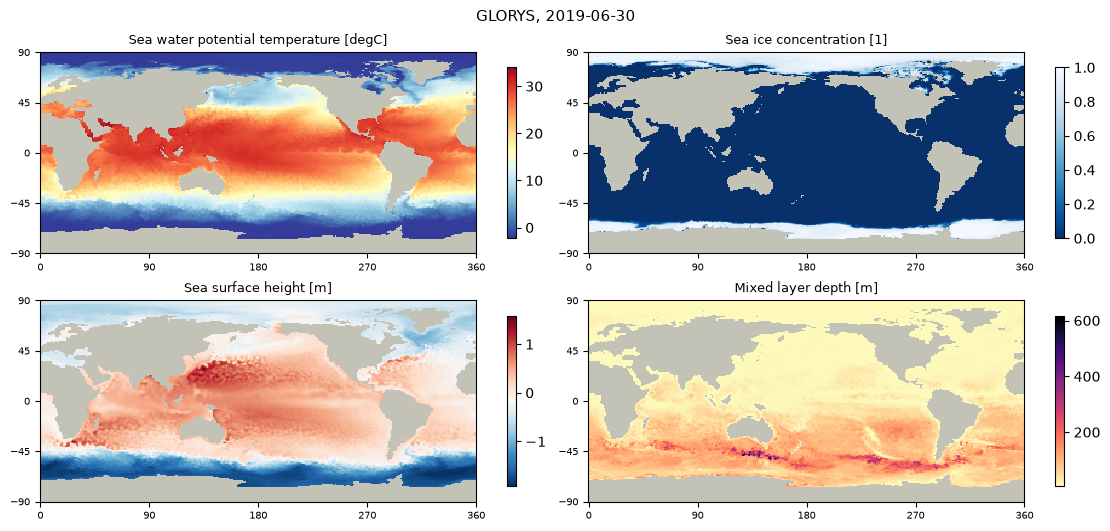

In [ ]:
def worldmap(ax, field, title, cmap="viridis", vmin=None, vmax=None):
    """One 180x360 field on a plain lat/lon axes, with land in grey."""
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad(LAND)
    im = ax.pcolormesh(
        np.arange(360), np.arange(-89.5, 90), np.ma.masked_invalid(field),
        cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest",
    )
    ax.set_title(title, fontsize=9)
    ax.set_xticks([0, 90, 180, 270, 360])
    ax.set_yticks([-90, -45, 0, 45, 90])
    ax.tick_params(labelsize=7)
    ax.set_facecolor(LAND)
    return im


fields = [
    ("thetao", state["level"][ds.level_variables.index("thetao"), 0], "RdYlBu_r"),
    ("siconc", state["surface"][ds.surface_variables.index("siconc"), 0], "Blues_r"),
    ("zos", state["surface"][ds.surface_variables.index("zos"), 0], "RdBu_r"),
    ("mlotst", state["surface"][ds.surface_variables.index("mlotst"), 0], "magma_r"),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 5.2), constrained_layout=True)
for ax, (name, field, cmap) in zip(axes.ravel(), fields):
    v = VARIABLES[name]
    im = worldmap(ax, field.numpy(), f"{v.long_name} [{v.units}]", cmap)
    fig.colorbar(im, ax=ax, shrink=0.85)
fig.suptitle(f"GLORYS, {np.datetime64(int(when), 's').astype('datetime64[D]')}", fontsize=11)
plt.show()

Things to notice:

* **`thetao` at 0.49 m is the sea surface temperature.** Warm belt at the
  equator, cold at both poles. This is the headline variable of the challenge.
* **`siconc` is a fraction in [0, 1].** It is 0 almost everywhere and only
  non-zero at the two poles. In June the Arctic is melting and the Antarctic is
  growing.
* **`zos`, sea surface height, is a map of the circulation.** The Gulf Stream
  and the Kuroshio show up as sharp gradients: water piles up on one side of a
  current and dips on the other.
* **`mlotst`, the mixed layer depth**, is how deep the wind and surface cooling
  have stirred the water column into a uniform slab. Deep in the winter
  hemisphere (here the south), shallow in the summer one.
* The bottom ~7% of every map is blank. That is not a plotting bug: GLORYS
  covers latitudes from -80 up, so the southernmost 13 rows are empty.

## 2. The land mask is three-dimensional

30.4% of the grid is land at the surface. Every depth level has its **own**
coastline, because a cell on the continental shelf is ocean at 5 m and rock at
300 m.

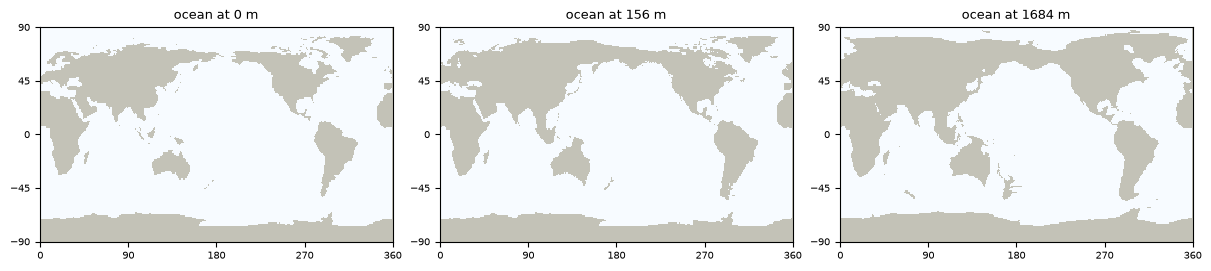

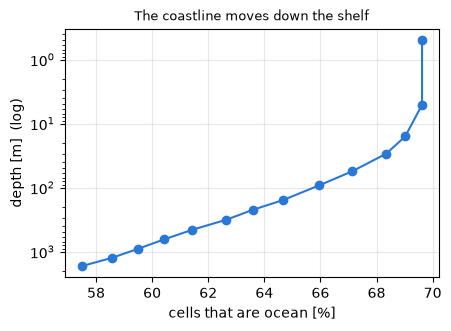

In [ ]:
masks = load_masks()
wet = masks.wet_level.numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 2.6), constrained_layout=True)
for ax, k in zip(axes, [0, 6, 13]):
    worldmap(ax, np.where(wet[k], 1.0, np.nan), f"ocean at {masks.depths[k]:.0f} m", "Blues")
plt.show()

frac = 100 * wet.reshape(len(masks.depths), -1).mean(1)
fig, ax = plt.subplots(figsize=(4.4, 3.2), constrained_layout=True)
ax.plot(frac, masks.depths, "o-", color="#2a78d6")
ax.invert_yaxis()
ax.set_yscale("log")
ax.set_xlabel("cells that are ocean [%]")
ax.set_ylabel("depth [m]  (log)")
ax.set_title("The coastline moves down the shelf", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

for d, f in zip(masks.depths, frac):
    print(f"  {d:8.2f} m   ocean {f:5.2f} %   land {100 - f:5.2f} %")

30.4% land at the surface, **42.5% at 1684 m**. In the raw archive it reaches
58.9% at 3993 m, and native level 49 (5728 m) is 100% NaN -- a whole level of
nothing.

This is why the loss and every metric use the **per-depth** mask. Scoring a
1684 m field with the surface mask would call the whole continental shelf
"ocean" and grade your model on rock.

## 3. NaN that means zero

The four sea-ice variables carry `cell_methods = "area: mean where sea_ice"`.
The value is an average over the *ice-covered part* of the cell -- so where
there is no ice there is nothing to average, and GLORYS writes NaN.

**Those NaNs are over open ocean, and they mean zero.** Feed them to a network
unchanged and you get NaN gradients.

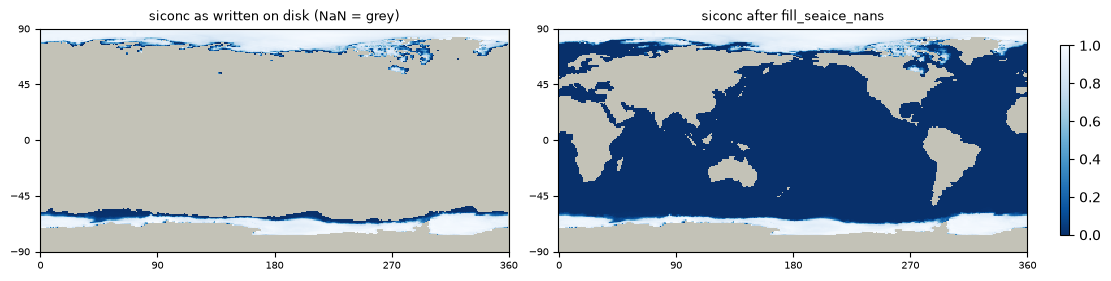

In [ ]:
raw = GlorysDataset(domain="tiny_val", fill_seaice=False)
filled = GlorysDataset(domain="tiny_val", fill_seaice=True)
c = raw.surface_variables.index("siconc")
ocean = masks.wet_surface.numpy()

i = day_index(raw, DAY)
a = raw[i]["surface"][c, 0].numpy()
b = filled[i]["surface"][c, 0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 2.7), constrained_layout=True)
worldmap(axes[0], a, "siconc as written on disk (NaN = grey)", "Blues_r", 0, 1)
im = worldmap(axes[1], b, "siconc after fill_seaice_nans", "Blues_r", 0, 1)
fig.colorbar(im, ax=axes[1], shrink=0.85)
plt.show()

print(f"on disk : {int((np.isnan(a) & ocean).sum()):6d} NaN cells over OCEAN (not land)")
print(f"filled  : {int((np.isnan(b) & ocean).sum()):6d}")
print(f"land is {int((~ocean).sum())} cells and stays NaN at this stage on purpose")

The left map is almost entirely grey, and none of that grey is land. After the
fill, only the real continents are missing.

## 4. GLORYS changed its mind on 2015-12-30

It gets worse. Until 2015-12-29 GLORYS wrote an exact `0.0` over ice-free ocean
for `usi`/`vsi`. From 2015-12-30 it writes NaN there instead. Nothing happened
to the ice; the file convention changed.

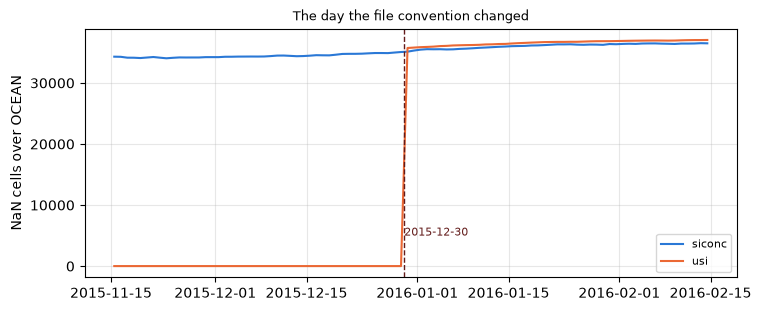

In [ ]:
span = GlorysDataset(
    domain="all", fill_seaice=False, return_timestamp=True,
    variables=dict(surface=["siconc", "usi"]),
)
times = np.array([t[2] for t in span.timestamps], dtype="datetime64[s]")
window = np.where(
    (times >= np.datetime64("2015-11-15")) & (times < np.datetime64("2016-02-15"))
)[0]

counts = {"siconc": [], "usi": []}
for i in window:
    field, _ = span[int(i)]
    for name in counts:
        j = span.surface_variables.index(name)
        counts[name].append(int((np.isnan(field["surface"][j, 0].numpy()) & ocean).sum()))

fig, ax = plt.subplots(figsize=(7.5, 3), constrained_layout=True)
for name, colour in (("siconc", "#2a78d6"), ("usi", "#eb6834")):
    ax.plot(times[window], counts[name], label=name, color=colour)
ax.axvline(np.datetime64("2015-12-30"), color="#621b1a", ls="--", lw=1)
ax.annotate("2015-12-30", (np.datetime64("2015-12-30"), 5000), fontsize=8, color="#621b1a")
ax.set_ylabel("NaN cells over OCEAN")
ax.set_title("The day the file convention changed", fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print("usi, NaN cells over ocean:")
for day in ("2015-12-29", "2015-12-30"):
    k = int(np.where(times == np.datetime64(day + "T12:00:00"))[0][0])
    field, _ = span[k]
    j = span.surface_variables.index("usi")
    print(f"  {day}: {int((np.isnan(field['surface'][j, 0].numpy()) & ocean).sum()):6d}")

**10 cells one day, 35 724 the next.** `siconc` is flat across the switch,
because it has always been NaN over ice-free ocean.

Why this matters to you: every year from 2016 on is validation, test or
holdout. A model trained without the fill would see one convention while
training and a different one at every evaluation.

`Variable.nan_means_zero` in `variables.py` flags the four affected fields and
`masks.fill_seaice_nans` handles them, before normalisation. The order matters
-- see section 7 below.

## 5. Two days are missing from the archive

2003-02-07 and 2003-02-11 do not exist. Not corrupted -- absent.

In [ ]:
all_times = np.array(
    [t[2] for t in GlorysDataset(domain="all", variables=dict(surface=["zos"])).timestamps],
    dtype="datetime64[s]",
)
gaps = np.diff(all_times).astype("timedelta64[h]").astype(int)
print(f"{len(all_times)} daily fields, {all_times[0]} to {all_times[-1]}")
for i in np.where(gaps != 24)[0]:
    print(f"  gap: {all_times[i]} -> {all_times[i + 1]}   ({gaps[i]} hours)")

The obvious way to build a forecasting dataset is index arithmetic: sample `i`
is the input, sample `i + 1` is the target one day later. Across that gap
`i + 1` is **two** days later and nothing tells you. Four training samples
would be silently labelled 1-day forecasts when they are 2-day forecasts.

`GlorysForecast` validates the real timestamps instead, and drops what does not
line up.

In [ ]:
for domain in ("train", "val", "test", "holdout", "tiny_train", "tiny_val"):
    f = GlorysForecast(domain=domain, variables=dict(surface=["zos"]))
    lo, hi = f.state_timestamp_range()
    print(
        f"{domain:11s} {len(f):5d} samples   dropped: {f.n_dropped_at_edges} at the edges, "
        f"{f.n_dropped_by_time_check} by the timestamp check   {lo} .. {hi}"
    )

The `4` in the `train` row is the neighbours of the two missing days. The `2`
in every row is the first state (no previous state) and the last (no next
state).

## 6. Sea ice: the seasonal cycle, and a number that looks wrong

**Sea ice extent** is the standard diagnostic: the total area of every ocean
cell whose concentration exceeds 15%.

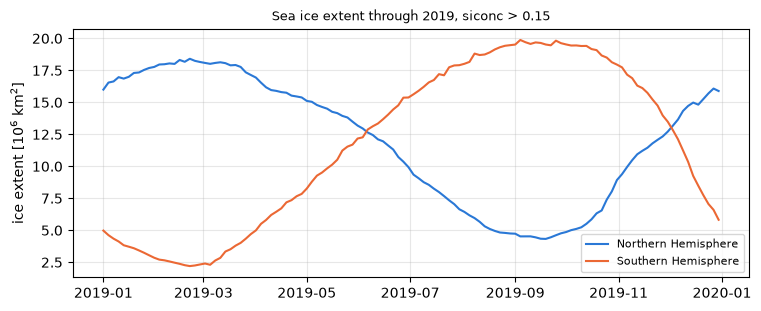

In [ ]:
areas = (cell_areas() * masks.wet_surface).numpy() / 1e6  # 10^6 km^2
nh, sh = (m.numpy() for m in hemisphere_masks())

ice = GlorysDataset(domain="tiny_val", return_timestamp=True, variables=dict(surface=["siconc"]))
ice_times = np.array([t[2] for t in ice.timestamps], dtype="datetime64[s]")
inside = np.where((ice_times >= np.datetime64("2019-01-01")) & (ice_times < np.datetime64("2020-01-01")))[0]
step = 3  # every third day is plenty and keeps this cell under a minute

days, nh_extent, sh_extent = [], [], []
for i in inside[::step]:
    field, when = ice[int(i)]
    conc = np.nan_to_num(field["surface"][0, 0].numpy())
    days.append(np.datetime64(int(when), "s").astype("datetime64[D]"))
    nh_extent.append(float((areas * nh * (conc > 0.15)).sum()))
    sh_extent.append(float((areas * sh * (conc > 0.15)).sum()))

fig, ax = plt.subplots(figsize=(7.5, 3), constrained_layout=True)
ax.plot(days, nh_extent, color="#2a78d6", label="Northern Hemisphere")
ax.plot(days, sh_extent, color="#eb6834", label="Southern Hemisphere")
ax.set_ylabel("ice extent [10$^6$ km$^2$]")
ax.set_title("Sea ice extent through 2019, siconc > 0.15", fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print(f"NH maximum {max(nh_extent):.2f} in {days[int(np.argmax(nh_extent))]}")
print(f"NH minimum {min(nh_extent):.2f} in {days[int(np.argmin(nh_extent))]}")
print(f"SH maximum {max(sh_extent):.2f} in {days[int(np.argmax(sh_extent))]}")
print(f"SH minimum {min(sh_extent):.2f} in {days[int(np.argmin(sh_extent))]}")

The two hemispheres are exactly out of phase: the northern maximum falls in
late winter (February-March) and the southern in September, with the minima six
months later. Good -- that is the check that no calendar index is shifted
anywhere in the pipeline. (This cell samples every third day, so the exact date
of a maximum can be a couple of days off.)

**But the Arctic March number is about 18, and published satellite figures are
14-16.** Do not go looking for a bug. The area integral is right; the regrid is
the reason. GLORYS is natively 1/12 degree, and averaging onto 1-degree cells
smears the ice edge: a cell that was 90% open water comes out at a
concentration of 0.1-0.3, clears the 15% threshold, and then contributes its
**whole** area.

In [ ]:
march = [i for i in inside if str(ice_times[i])[5:7] == "03"]
for threshold in (0.15, 0.30, 0.50, 0.80):
    vals = []
    for i in march:
        conc = np.nan_to_num(ice[int(i)][0]["surface"][0, 0].numpy())
        vals.append(float((areas * nh * (conc > threshold)).sum()))
    print(f"threshold {threshold:.2f}:  March 2019 mean {np.mean(vals):5.2f}   daily max {np.max(vals):5.2f}")

At a 0.8 threshold the same days give ~14.6, right where the published number
is. **Compare your model against the truth on this grid**, which is what every
metric in this kit does -- not against a satellite product on another one.

## 7. What the model actually sees

`GlorysForecast` applies four steps, in this order:

```
1. read the raw field            land = NaN, ice-free ocean = NaN
2. fill_seaice_nans              ice-free ocean -> 0  (physical units)
3. normalise (x - mean) / std
4. nan_to_num(0.0)               what is still NaN is land -> 0
```

Steps 2 and 3 must stay in that order.

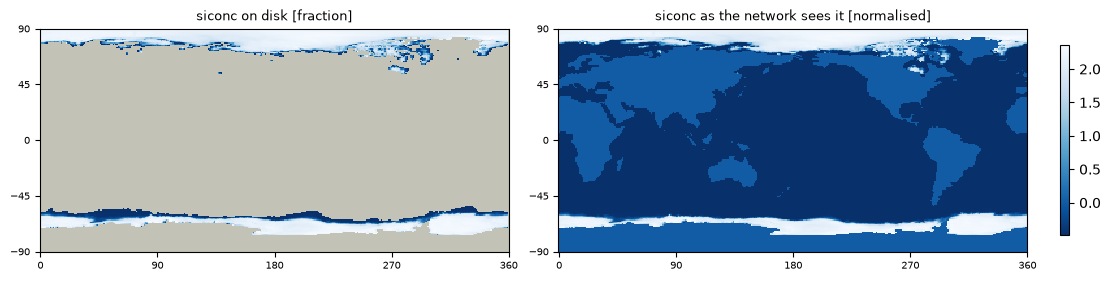

In [ ]:
fc = GlorysForecast(domain="tiny_val")
on_disk = GlorysForecast(domain="tiny_val", fill_seaice=False, norm_scheme=None, nan_to_num=False)

c = fc.surface_variables.index("siconc")
mean = float(fc.data_mean["surface"][c])
std = float(fc.data_std["surface"][c])
i = day_index(fc, DAY)
raw_field = on_disk[i]["state"]["surface"][c, 0].numpy()
seen = fc[i]["state"]["surface"][c, 0].numpy()
icefree = np.isnan(raw_field) & ocean

print(f"siconc  mean {mean:.4f}  std {std:.4f}   ->  -mean/std = {-mean / std:.4f}")
print(f"ice-free ocean ({int(icefree.sum())} cells) reaches the model as {np.unique(seen[icefree].round(4))}")
print(f"land           ({int((~ocean).sum())} cells) reaches the model as {np.unique(seen[~ocean].round(4))}")

fig, axes = plt.subplots(1, 2, figsize=(11, 2.7), constrained_layout=True)
worldmap(axes[0], raw_field, "siconc on disk [fraction]", "Blues_r", 0, 1)
im = worldmap(axes[1], seen, "siconc as the network sees it [normalised]", "Blues_r")
fig.colorbar(im, ax=axes[1], shrink=0.85)
plt.show()

* **Ice-free ocean becomes `-mean/std`** -- the normalised representation of a
  real physical zero. Correct: there genuinely is no ice there.
* **Land becomes exactly `0`**, which after normalisation is the climatological
  mean, the least disruptive thing to hand a network.

Swap steps 2 and 3 and ice-free ocean would come out as `0`, i.e. you would be
telling the model that open water has the global mean ice concentration of
0.17. Nothing crashes. The training is quietly poisoned.

## 8. How fast does the ocean actually change?

This is the most important cell in the notebook, because it tells you how good
your forecast has to be before it is worth anything.

We take a state, wait *k* days, and measure how far the ocean has moved. That
is exactly the error a **persistence** forecast -- "tomorrow looks like today"
-- makes at lead time *k*.

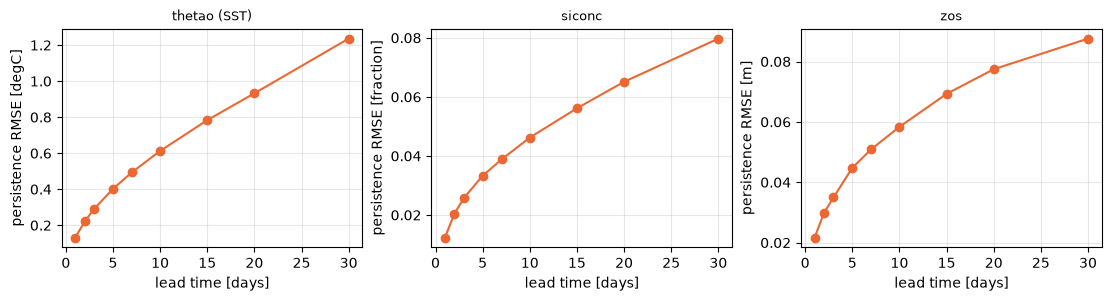

In [ ]:
probe = GlorysDataset(
    domain="tiny_val", return_timestamp=True,
    variables=dict(surface=["zos", "siconc"], level=["thetao"]), depth_indices=[0],
)
probe_mask = probe.state_mask()
lat = torch.cos(torch.deg2rad(torch.arange(-89.5, 90))).reshape(-1, 1)

def ocean_rmse(a, b, mask):
    """Latitude-weighted RMSE over ocean cells. Land is NaN here, and NaN * 0 is
    still NaN, so the land cells have to be removed rather than down-weighted."""
    w = mask * lat
    err = torch.nan_to_num((a - b) ** 2, nan=0.0)
    return float(((err * w).sum() / w.sum()).sqrt())


leads = [1, 2, 3, 5, 7, 10, 15, 20, 30]
first = day_index(probe, "2019-01-02")
starts = list(range(first, first + 300, 12))   # 25 initial days through 2019
curves = {"thetao (SST)": [], "siconc": [], "zos": []}
cache = {}

def get(i):
    if i not in cache:
        cache[i] = probe[i][0]
    return cache[i]

for k in leads:
    per_var = {n: [] for n in curves}
    for s in starts:
        a, b = get(s), get(s + k)
        per_var["thetao (SST)"].append(ocean_rmse(a["level"][0], b["level"][0], probe_mask["level"][0]))
        per_var["siconc"].append(ocean_rmse(a["surface"][1, 0], b["surface"][1, 0], probe_mask["surface"][0, 0]))
        per_var["zos"].append(ocean_rmse(a["surface"][0, 0], b["surface"][0, 0], probe_mask["surface"][0, 0]))
    for n in curves:
        curves[n].append(float(np.mean(per_var[n])))

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9), constrained_layout=True)
units = {"thetao (SST)": "degC", "siconc": "fraction", "zos": "m"}
for ax, (name, values) in zip(axes, curves.items()):
    ax.plot(leads, values, "o-", color="#eb6834")
    ax.set_xlabel("lead time [days]")
    ax.set_ylabel(f"persistence RMSE [{units[name]}]")
    ax.set_title(name, fontsize=9)
    ax.grid(alpha=0.3)
plt.show()

print(f"{'lead':>5}  {'thetao [degC]':>14}  {'siconc':>10}  {'zos [m]':>10}")
for i, k in enumerate(leads):
    print(f"{k:5d}  {curves['thetao (SST)'][i]:14.4f}  {curves['siconc'][i]:10.5f}  {curves['zos'][i]:10.5f}")

Read those numbers carefully.

* **Sea surface temperature moves about 0.13 degC in a day**, against a
  global spread of 11.7 degC. The trained `tiny` model in this kit gets 0.125.
  That is a ~4% improvement over doing nothing at all.
* The curves rise **slowly and smoothly**. The atmosphere would have saturated
  in a week; the ocean is still climbing at 30 days.
* `siconc` grows the fastest in relative terms -- the ice edge really does move.

**This is why you never report an error without a baseline beside it.** An SST
RMSE of 0.2 degC sounds excellent and is worse than copying yesterday.

The training loss in this kit is built to make that comparison automatic: each
error is divided by `delta_std`, the standard deviation of the one-day change,
so a persistence forecast scores about 1 (measured: 0.81-0.87, depending on the
split). **A training loss below ~0.82 means you are beating persistence.**

## Where to go next

* [`docs/02_data_and_masking.md`](../docs/02_data_and_masking.md) -- all of the
  above in words, plus the parts this notebook skipped (`uo`/`vo` NaN at 630
  cells the mask calls ocean, and why land must be out of the loss).
* [`docs/03_first_model.md`](../docs/03_first_model.md) -- train something.
* [`notebooks/02_train_and_rollout.ipynb`](02_train_and_rollout.ipynb) -- do it
  in a notebook, on a GPU.